In [2]:
!pip install prophet xgboost statsmodels streamlit plotly -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 93.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 104.6 MB/s eta 0:00:00


In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

In [17]:
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [18]:
print(df.shape)
df.info()
df.describe()

(9800, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dt

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [26]:
print("Missing Values")
print(df.isnull().sum())
print()
print("Duplicate Rows :", df.duplicated().sum())

Missing Values
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Duplicate Rows : 0


In [27]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [28]:
df["Year"] = df["Order Date"].dt.year

df["Month"] = df["Order Date"].dt.month

df["Week"] = df["Order Date"].dt.isocalendar().week

df["Day"] = df["Order Date"].dt.day_name()

df["Quarter"] = df["Order Date"].dt.quarter

season = {
    12:"Winter",
    1:"Winter",
    2:"Winter",
    3:"Spring",
    4:"Spring",
    5:"Spring",
    6:"Summer",
    7:"Summer",
    8:"Summer",
    9:"Autumn",
    10:"Autumn",
    11:"Autumn"
}

df["Season"] = df["Month"].map(season)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Week,Day,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Autumn


In [29]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df[["Order Date","Ship Date","Shipping Days"]].head()

,Order Date,Ship Date,Shipping Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


In [30]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
    .sum()
)

weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date",freq="W"))["Sales"]
    .sum()
)

monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date",freq="ME"))["Sales"]
    .sum()
)

print(daily_sales.head())

print(weekly_sales.head())

print(monthly_sales.head())

Order Date
2015-01-03      16.448
2015-01-04     288.060
2015-01-05      19.536
2015-01-06    4407.100
2015-01-07      87.158
Name: Sales, dtype: float64
Order Date
2015-01-04     304.508
2015-01-11    4619.108
2015-01-18    4130.533
2015-01-25    3092.544
2015-02-01    2527.914
Freq: W-SUN, Name: Sales, dtype: float64
Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64


Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


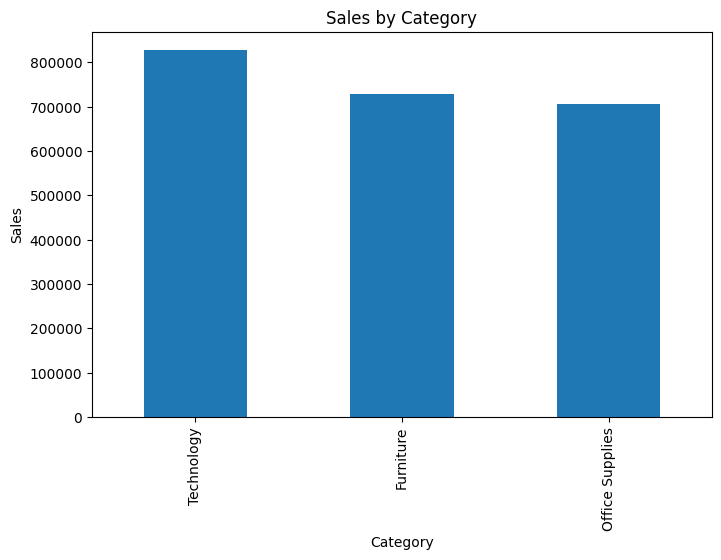

In [31]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Sales by Category")

plt.ylabel("Sales")

plt.show()

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


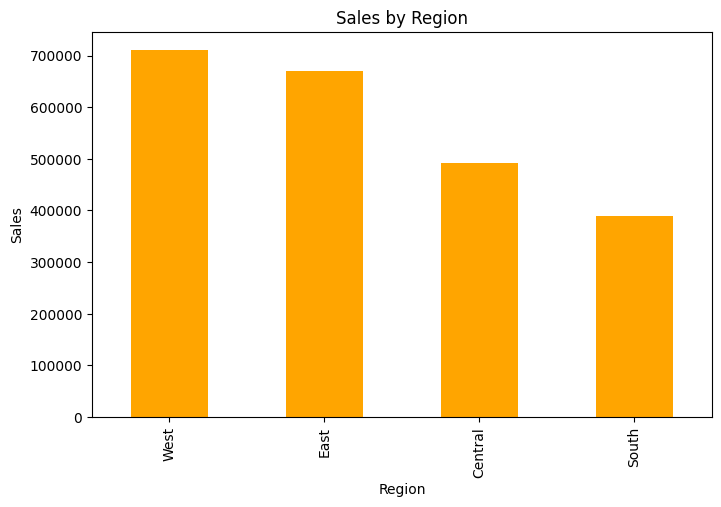

In [32]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(region_sales)

plt.figure(figsize=(8,5))

region_sales.plot(kind="bar",color="orange")

plt.title("Sales by Region")

plt.ylabel("Sales")

plt.show()

Region
Central    4.065876
East       3.910233
South      3.961202
West       3.930255
Name: Shipping Days, dtype: float64


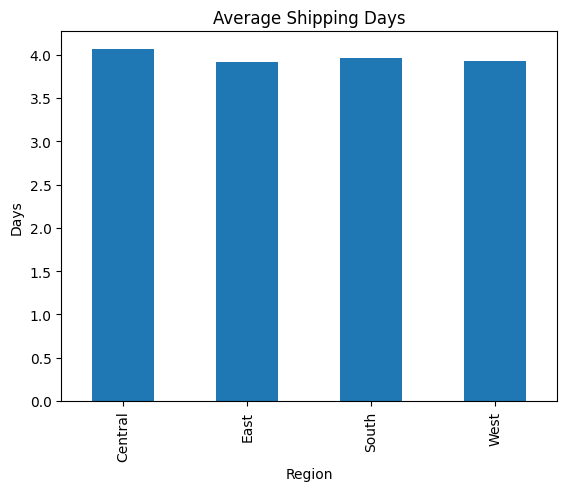

In [33]:
avg_shipping = (
    df.groupby("Region")["Shipping Days"]
    .mean()
)

print(avg_shipping)

avg_shipping.plot(kind="bar")

plt.title("Average Shipping Days")

plt.ylabel("Days")

plt.show()

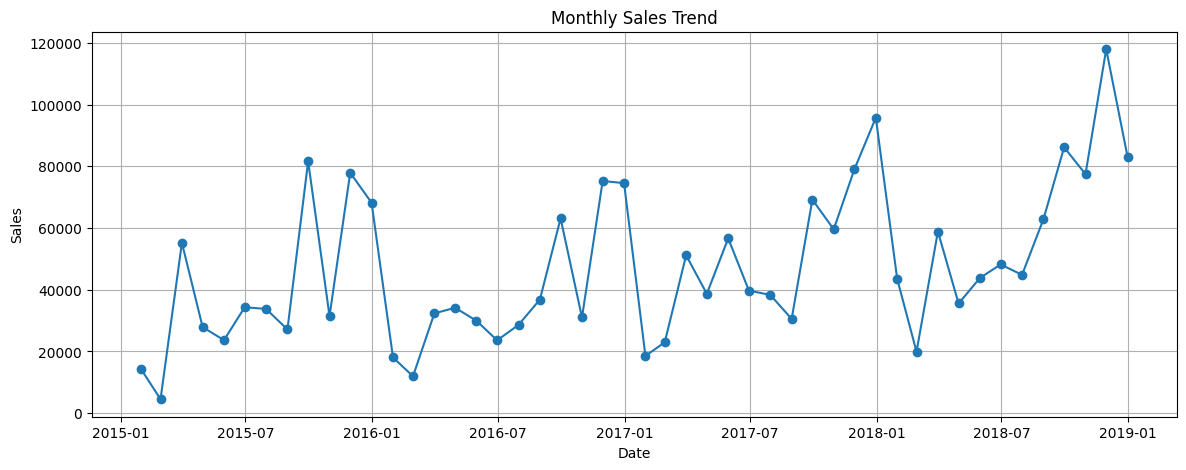

In [34]:
plt.figure(figsize=(14,5))

plt.plot(monthly_sales.index,monthly_sales.values,marker="o")

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

Month
1     257.627403
2     199.902745
3     290.549393
4     207.432269
5     212.533412
6     211.052856
7     208.802997
8     227.007110
9     221.642106
10    246.596162
11    241.657496
12    232.619515
Name: Sales, dtype: float64


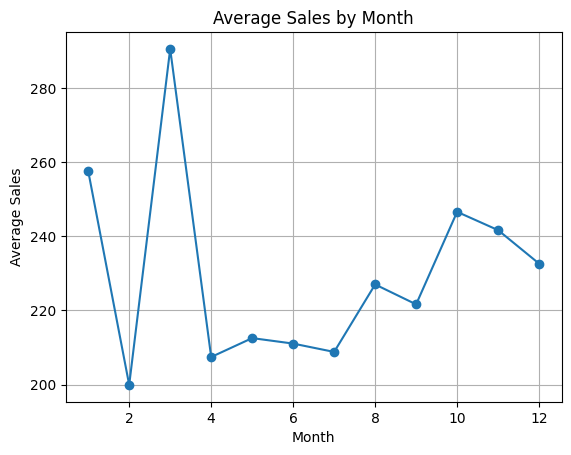

In [35]:
seasonality = (
    df.groupby("Month")["Sales"]
    .mean()
)

print(seasonality)

seasonality.plot(marker="o")

plt.title("Average Sales by Month")

plt.xlabel("Month")

plt.ylabel("Average Sales")

plt.grid(True)

plt.show()

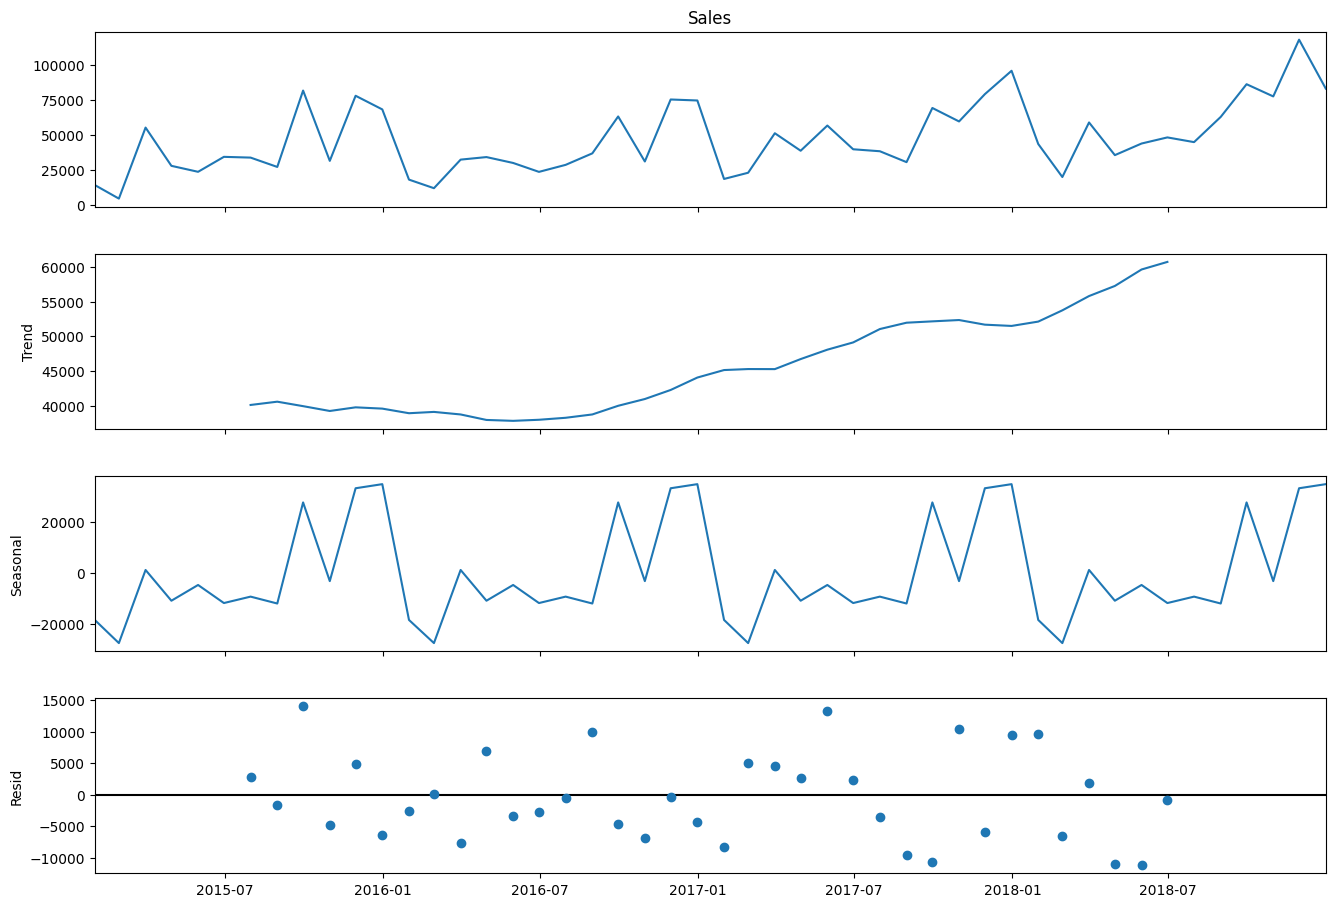

In [37]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(15,10)
plt.show()

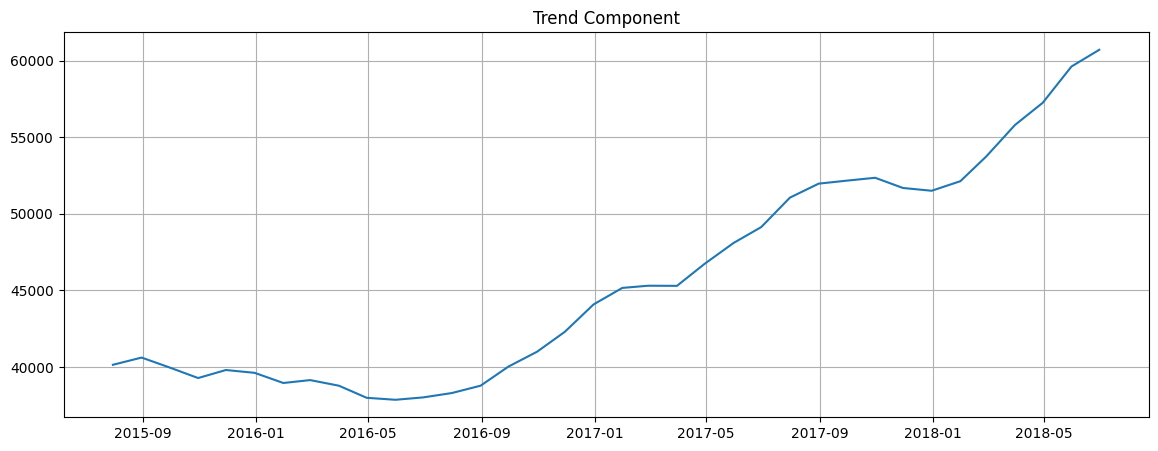

In [38]:
plt.figure(figsize=(14,5))
plt.plot(decomposition.trend)
plt.title("Trend Component")
plt.grid(True)
plt.show()

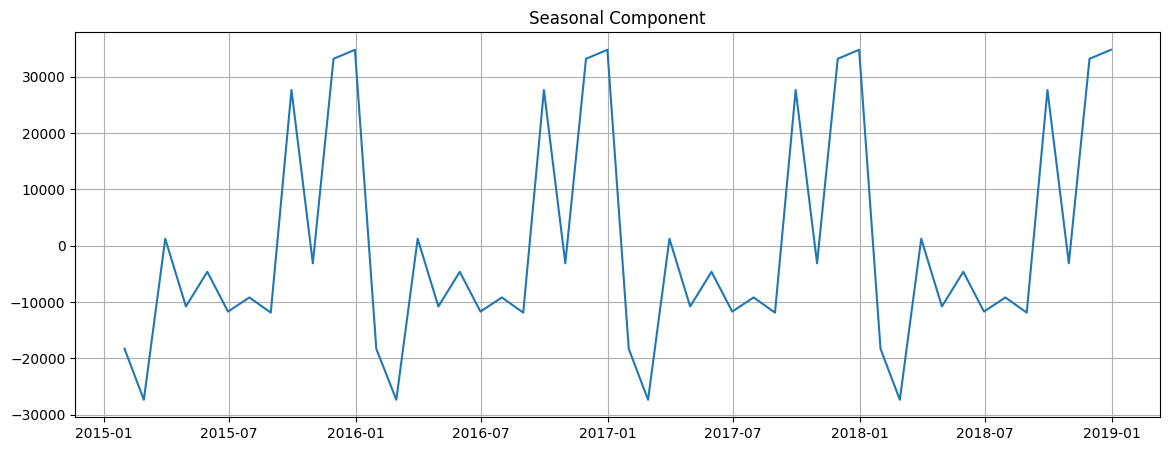

In [39]:
plt.figure(figsize=(14,5))
plt.plot(decomposition.seasonal)
plt.title("Seasonal Component")
plt.grid(True)
plt.show()

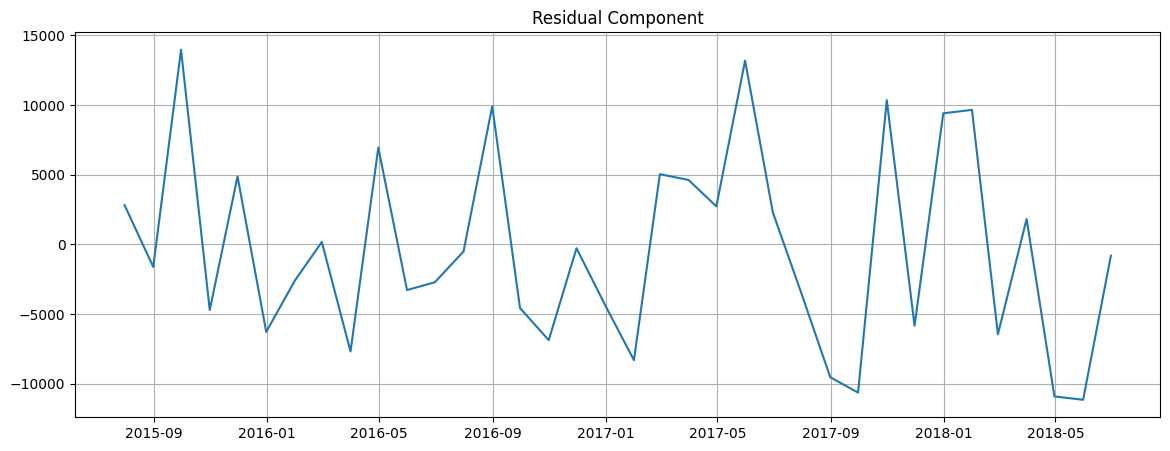

In [40]:
plt.figure(figsize=(14,5))
plt.plot(decomposition.resid)
plt.title("Residual Component")
plt.grid(True)
plt.show()

In [41]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales)

print("ADF Statistic :", result[0])

print("P-value :", result[1])

print()

for key,value in result[4].items():
    print(key,":",value)

ADF Statistic : -4.416136761430769
P-value : 0.00027791039276670623

1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


In [42]:
if result[1] < 0.05:
    print("Time Series is Stationary")
else:
    print("Time Series is Non-Stationary")

Time Series is Stationary


In [43]:
monthly_diff = monthly_sales.diff().dropna()

monthly_diff.head()

,Sales
Order Date,
2015-02-28,-9685.8150
2015-03-31,50685.9050
2015-04-30,-27298.9420
2015-05-31,-4262.5520
2015-06-30,10678.6326


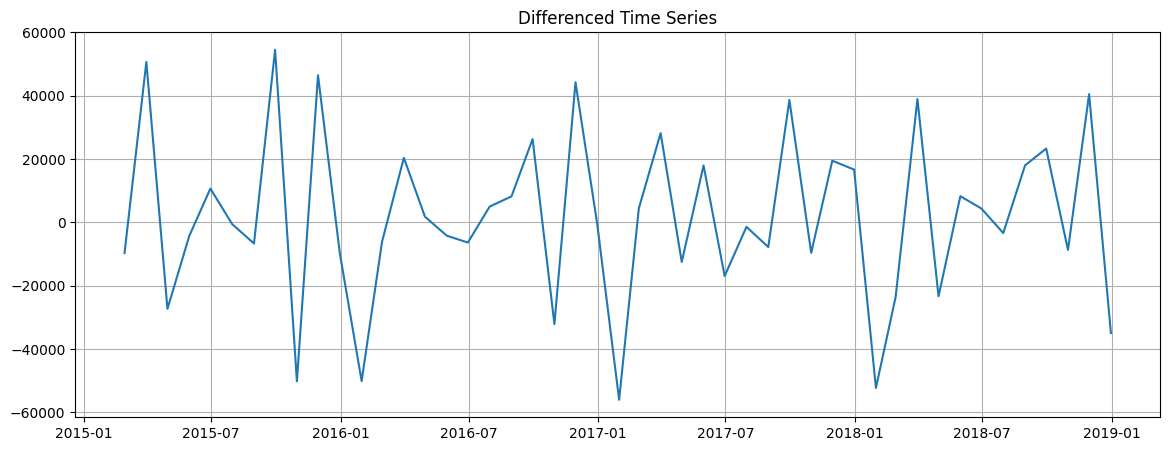

In [44]:
plt.figure(figsize=(14,5))
plt.plot(monthly_diff)
plt.title("Differenced Time Series")
plt.grid(True)
plt.show()

In [45]:
result2 = adfuller(monthly_diff)

print("ADF Statistic :",result2[0])

print("P-value :",result2[1])

print()

for key,value in result2[4].items():
    print(key,":",value)

ADF Statistic : -8.727061830353268
P-value : 3.2669175472796045e-14

1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


In [46]:
if result2[1] < 0.05:
    print("Differenced Series is Stationary")
else:
    print("Still Non-Stationary")

Differenced Series is Stationary


### Observations

1. The monthly sales data shows a clear upward trend over time.
2. Seasonal variations are visible, indicating recurring sales patterns.
3. The residual component represents random fluctuations not explained by trend or seasonality.
4. The original series may be non-stationary if the ADF test p-value is greater than 0.05.
5. After first-order differencing, the p-value decreases, indicating that the series becomes stationary.

In [47]:
train = monthly_sales[:-3]
test = monthly_sales[-3:]
print(train.shape)
print(test.shape)

(45,)
(3,)


In [48]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = sarima.fit()

print(sarima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -347.979
Date:                            Sun, 12 Jul 2026   AIC                            705.958
Time:                                    15:41:24   BIC                            713.287
Sample:                                01-31-2015   HQIC                           708.387
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5680      0.242      2.347      0.019       0.094       1.042
ma.L1         -0.8985      0.177   

In [49]:
forecast = sarima_model.get_forecast(steps=3)
sarima_pred = forecast.predicted_mean
conf = forecast.conf_int()

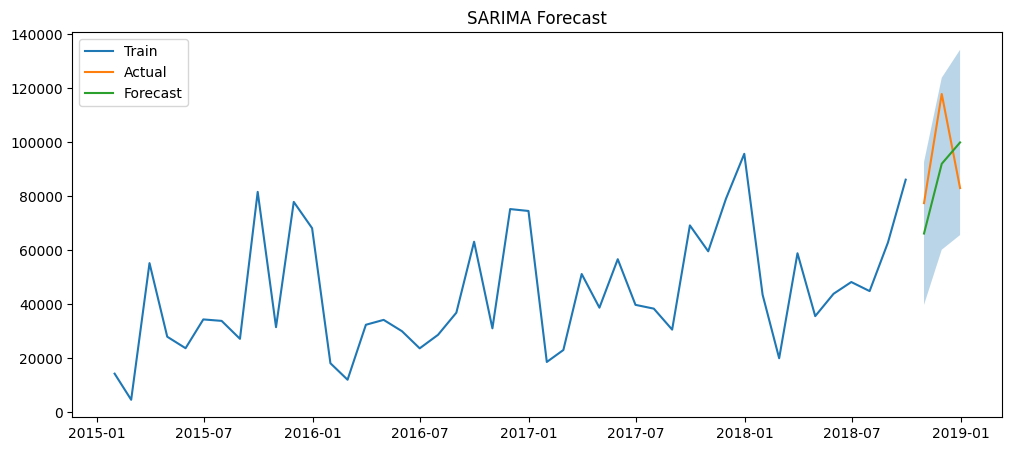

In [50]:
plt.figure(figsize=(12,5))
plt.plot(train.index,train,label="Train")
plt.plot(test.index,test,label="Actual")
plt.plot(test.index,sarima_pred,label="Forecast")
plt.fill_between(
    test.index,
    conf.iloc[:,0],
    conf.iloc[:,1],
    alpha=0.3
)
plt.legend()
plt.title("SARIMA Forecast")
plt.show()

In [51]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np
mae_sarima = mean_absolute_error(test,sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(test,sarima_pred))
mape_sarima = np.mean(np.abs((test-sarima_pred)/test))*100
print("MAE :",mae_sarima)
print("RMSE :",rmse_sarima)
print("MAPE :",mape_sarima)

MAE : 18031.40467222437
RMSE : 19009.18206635205
MAPE : 18.966498068433015


In [52]:
prophet_df = monthly_sales.reset_index()
prophet_df.columns=["ds","y"]
prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [53]:
from prophet import Prophet
model = Prophet()
model.fit(prophet_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [54]:
future = model.make_future_dataframe(periods=3,freq="M")
forecast = model.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
46,2018-11-30,60719.543484,91056.274430,110193.965910,60719.543484,60719.543484,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,0.0,0.0,0.0,101136.336967
47,2018-12-31,61457.486600,81885.877288,100290.241114,61457.486600,61457.486600,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,0.0,0.0,0.0,90673.800609
48,2019-01-31,62195.429716,34131.843022,51693.221523,62190.156877,62201.373948,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,42990.532205
49,2019-02-28,62861.958982,21658.307383,40032.459157,62844.825146,62880.331690,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,31248.159925
50,2019-03-31,63599.902097,71981.190929,89913.641668,63564.035218,63636.549658,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,81267.007775


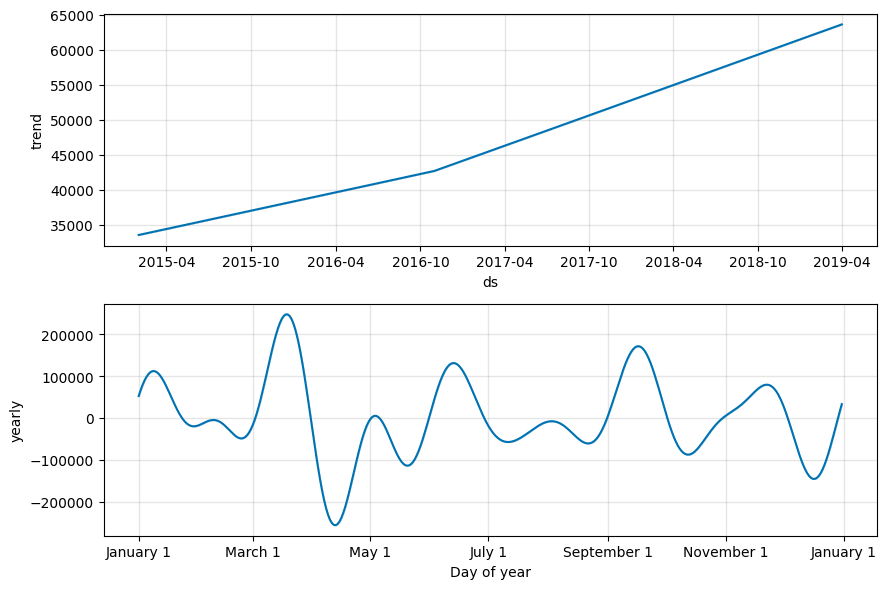

In [55]:
model.plot_components(forecast)
plt.show()

In [56]:
prophet_pred = forecast["yhat"].tail(3).values
actual = test.values
mae_prophet = mean_absolute_error(actual,prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(actual,prophet_pred))
mape_prophet = np.mean(np.abs((actual-prophet_pred)/actual))*100
print(mae_prophet)
print(rmse_prophet)
print(mape_prophet)

40970.32503170963
53868.94865405445
40.03986493644266


In [57]:
xgb_df = monthly_sales.reset_index()

xgb_df.columns = ["Date", "Sales"]

xgb_df["lag1"] = xgb_df["Sales"].shift(1)
xgb_df["lag2"] = xgb_df["Sales"].shift(2)
xgb_df["lag3"] = xgb_df["Sales"].shift(3)

xgb_df["rolling_mean"] = xgb_df["Sales"].rolling(3).mean()

xgb_df["month"] = xgb_df["Date"].dt.month
xgb_df["quarter"] = xgb_df["Date"].dt.quarter

season = {
    12:4,1:4,2:4,
    3:1,4:1,5:1,
    6:2,7:2,8:2,
    9:3,10:3,11:3
}

xgb_df["season"] = xgb_df["month"].map(season)

xgb_df = xgb_df.dropna()

xgb_df.head()

,Date,Sales,lag1,lag2,lag3,rolling_mean,month,quarter,season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


In [58]:
features = [
    "lag1",
    "lag2",
    "lag3",
    "rolling_mean",
    "month",
    "quarter",
    "season"
]

X = xgb_df[features]

y = xgb_df["Sales"]

In [59]:
X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

In [60]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [61]:
xgb_pred = xgb.predict(X_test)
print(xgb_pred)

[86785.234 87468.75  87828.09 ]


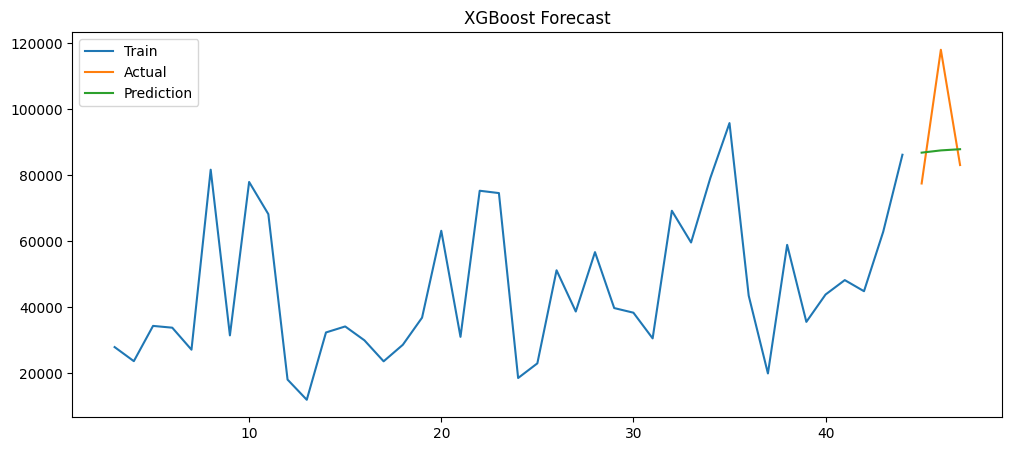

In [62]:
plt.figure(figsize=(12,5))
plt.plot(y_train.index, y_train.values, label="Train")
plt.plot(y_test.index, y_test.values, label="Actual")
plt.plot(y_test.index, xgb_pred, label="Prediction")
plt.legend()
plt.title("XGBoost Forecast")
plt.show()

In [63]:
mae_xgb = mean_absolute_error(y_test, xgb_pred)

rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))

mape_xgb = np.mean(
    np.abs((y_test - xgb_pred) / y_test)
) * 100
print("MAE :", mae_xgb)
print("RMSE :", rmse_xgb)
print("MAPE :", mape_xgb)

MAE : 14868.071041666664
RMSE : 18606.308155585964
MAPE : 14.556421901981054


In [64]:
comparison = pd.DataFrame({
    "Model":["SARIMA","Prophet","XGBoost"],
    "MAE":[mae_sarima,mae_prophet,mae_xgb],
    "RMSE":[rmse_sarima,rmse_prophet,rmse_xgb],
    "MAPE":[mape_sarima,mape_prophet,mape_xgb]
})
comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,18031.404672,19009.182066,18.966498
1,Prophet,40970.325032,53868.948654,40.039865
2,XGBoost,14868.071042,18606.308156,14.556422


In [65]:
best = comparison.sort_values("RMSE")
print(best)

     Model           MAE          RMSE       MAPE
2  XGBoost  14868.071042  18606.308156  14.556422
0   SARIMA  18031.404672  19009.182066  18.966498
1  Prophet  40970.325032  53868.948654  40.039865


In [66]:
comparison.to_csv("model_comparison.csv", index=False)

In [67]:
category_monthly = (
    df.groupby(
        [
            pd.Grouper(key="Order Date", freq="ME"),
            "Category"
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

category_monthly.head()

,Order Date,Category,Sales
0,2015-01-31,Furniture,6217.277
1,2015-01-31,Office Supplies,4845.140
2,2015-01-31,Technology,3143.290
3,2015-02-28,Furniture,1839.658
4,2015-02-28,Office Supplies,1071.724


In [68]:
region_monthly = (
    df.groupby(
        [
            pd.Grouper(key="Order Date", freq="ME"),
            "Region"
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

region_monthly.head()

,Order Date,Region,Sales
0,2015-01-31,Central,1533.966
1,2015-01-31,East,436.174
2,2015-01-31,South,9296.844
3,2015-01-31,West,2938.723
4,2015-02-28,Central,1233.174


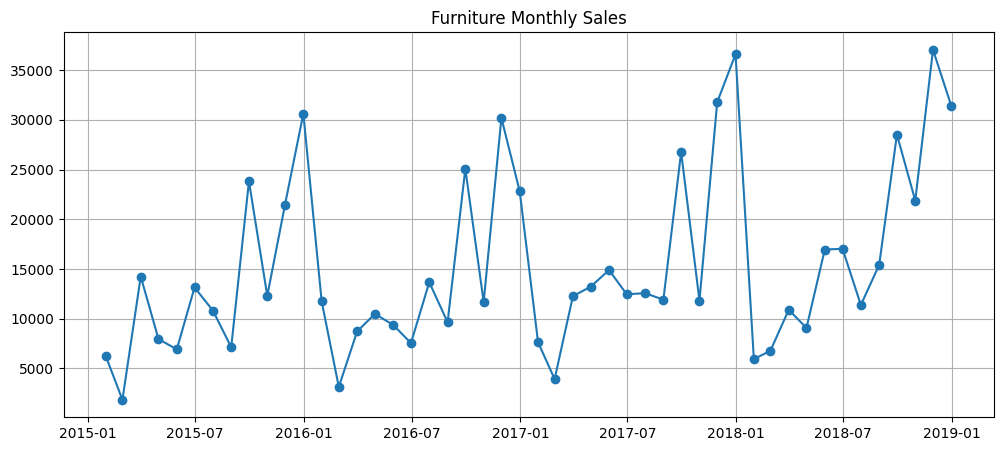

In [69]:
furniture = category_monthly[
    category_monthly["Category"] == "Furniture"
]

plt.figure(figsize=(12,5))

plt.plot(
    furniture["Order Date"],
    furniture["Sales"],
    marker="o"
)

plt.title("Furniture Monthly Sales")

plt.grid(True)

plt.show()

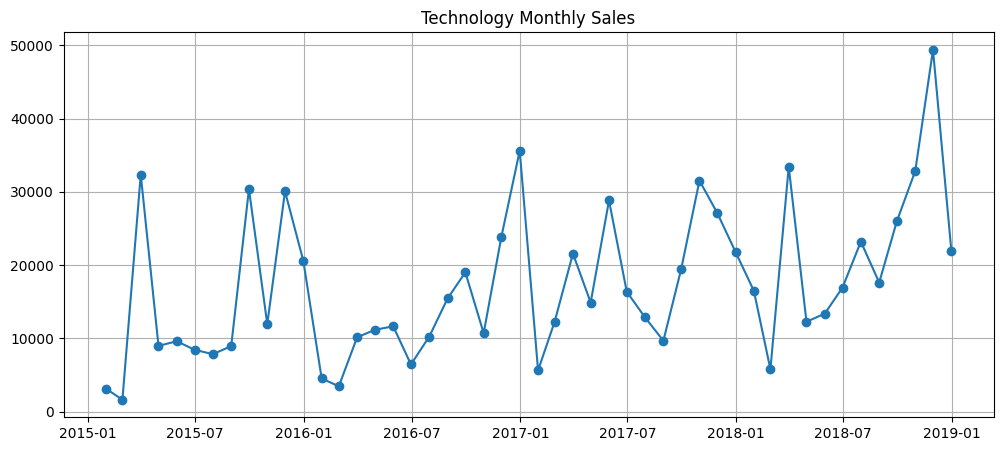

In [70]:
technology = category_monthly[
    category_monthly["Category"] == "Technology"
]

plt.figure(figsize=(12,5))

plt.plot(
    technology["Order Date"],
    technology["Sales"],
    marker="o"
)
plt.title("Technology Monthly Sales")
plt.grid(True)
plt.show()

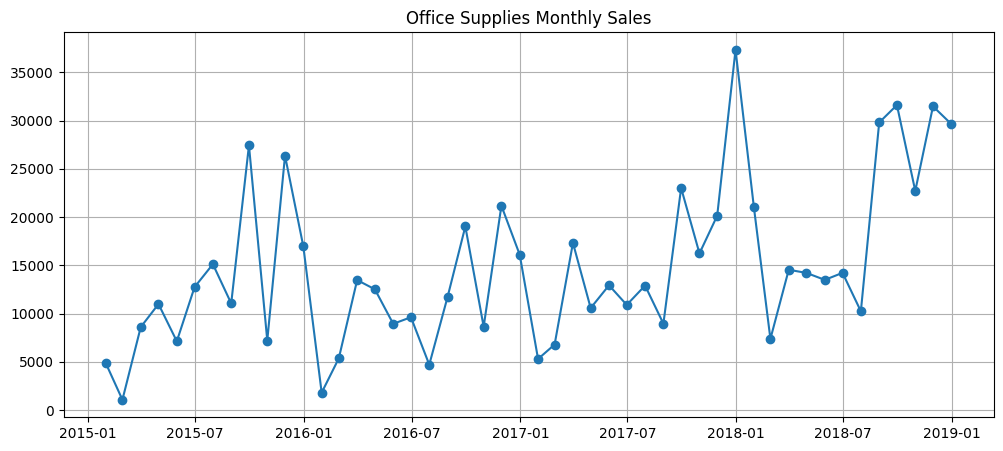

In [71]:
office = category_monthly[
    category_monthly["Category"] == "Office Supplies"
]

plt.figure(figsize=(12,5))

plt.plot(
    office["Order Date"],
    office["Sales"],
    marker="o"
)

plt.title("Office Supplies Monthly Sales")

plt.grid(True)

plt.show()

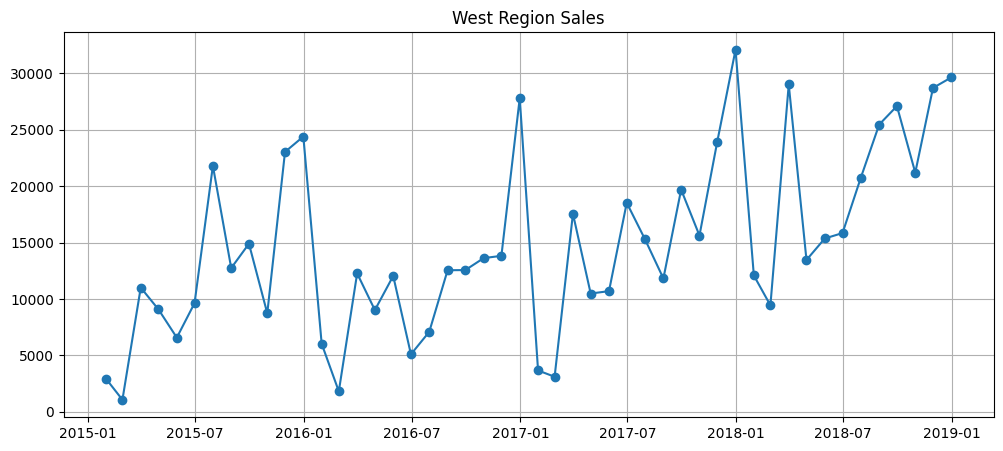

In [72]:
west = region_monthly[
    region_monthly["Region"] == "West"
]

plt.figure(figsize=(12,5))

plt.plot(
    west["Order Date"],
    west["Sales"],
    marker="o"
)
plt.title("West Region Sales")
plt.grid(True)
plt.show()

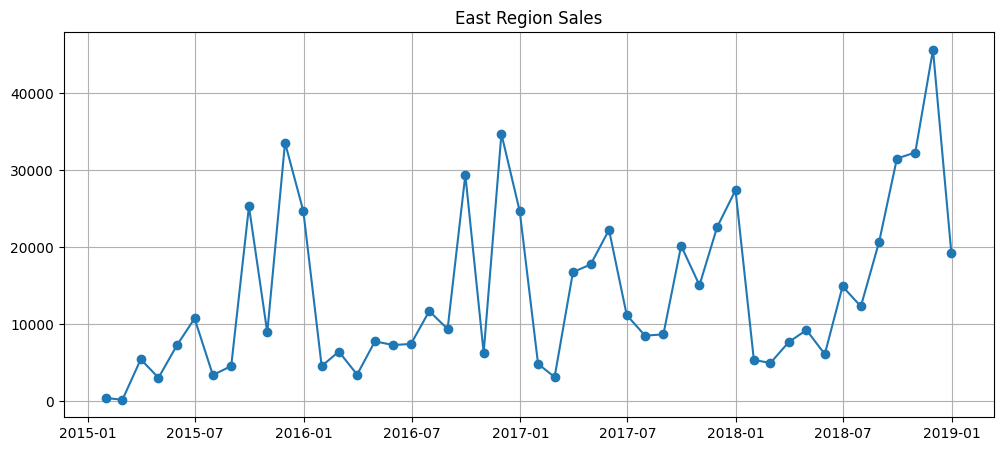

In [73]:
east = region_monthly[
    region_monthly["Region"] == "East"
]

plt.figure(figsize=(12,5))

plt.plot(
    east["Order Date"],
    east["Sales"],
    marker="o"
)
plt.title("East Region Sales")
plt.grid(True)
plt.show()

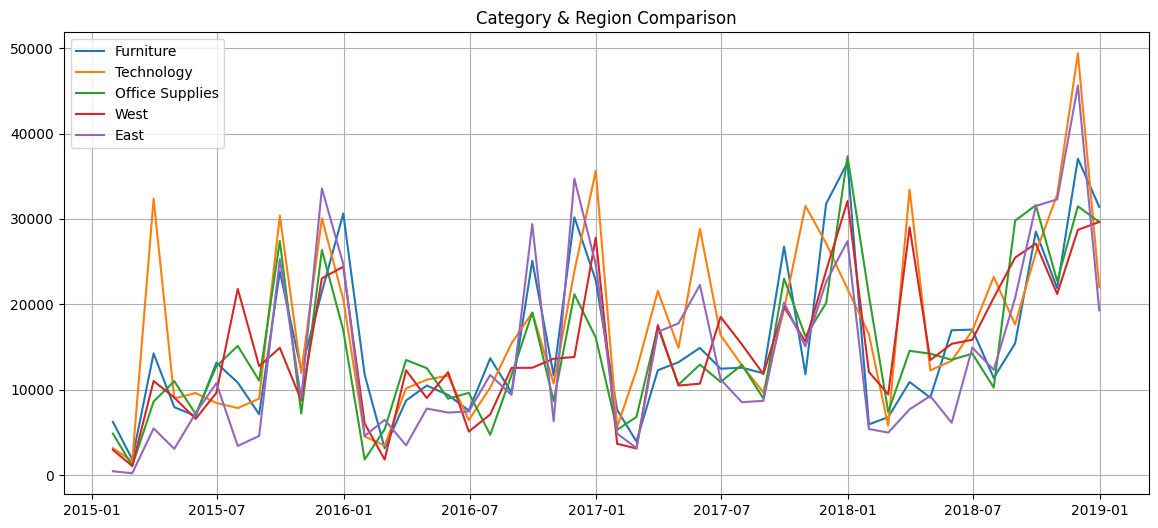

In [74]:
plt.figure(figsize=(14,6))

plt.plot(
    furniture["Order Date"],
    furniture["Sales"],
    label="Furniture"
)

plt.plot(
    technology["Order Date"],
    technology["Sales"],
    label="Technology"
)

plt.plot(
    office["Order Date"],
    office["Sales"],
    label="Office Supplies"
)

plt.plot(
    west["Order Date"],
    west["Sales"],
    label="West"
)

plt.plot(
    east["Order Date"],
    east["Sales"],
    label="East"
)

plt.legend()

plt.title("Category & Region Comparison")

plt.grid(True)

plt.show()

In [75]:
growth = pd.DataFrame({
    "Furniture":[furniture["Sales"].iloc[-1]],
    "Technology":[technology["Sales"].iloc[-1]],
    "Office Supplies":[office["Sales"].iloc[-1]],
    "West":[west["Sales"].iloc[-1]],
    "East":[east["Sales"].iloc[-1]]
})

growth.T.rename(columns={0:"Latest Monthly Sales"})

,Latest Monthly Sales
Furniture,31407.4668
Technology,21984.9100
Office Supplies,29638.0120
West,29652.0950
East,19285.4860


In [76]:
latest = {
    "Furniture": furniture["Sales"].iloc[-1],
    "Technology": technology["Sales"].iloc[-1],
    "Office Supplies": office["Sales"].iloc[-1],
    "West": west["Sales"].iloc[-1],
    "East": east["Sales"].iloc[-1]
}

best_segment = max(latest, key=latest.get)

print("Best Performing Segment:", best_segment)

Best Performing Segment: Furniture


In [78]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [79]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.03,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales.head()

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1


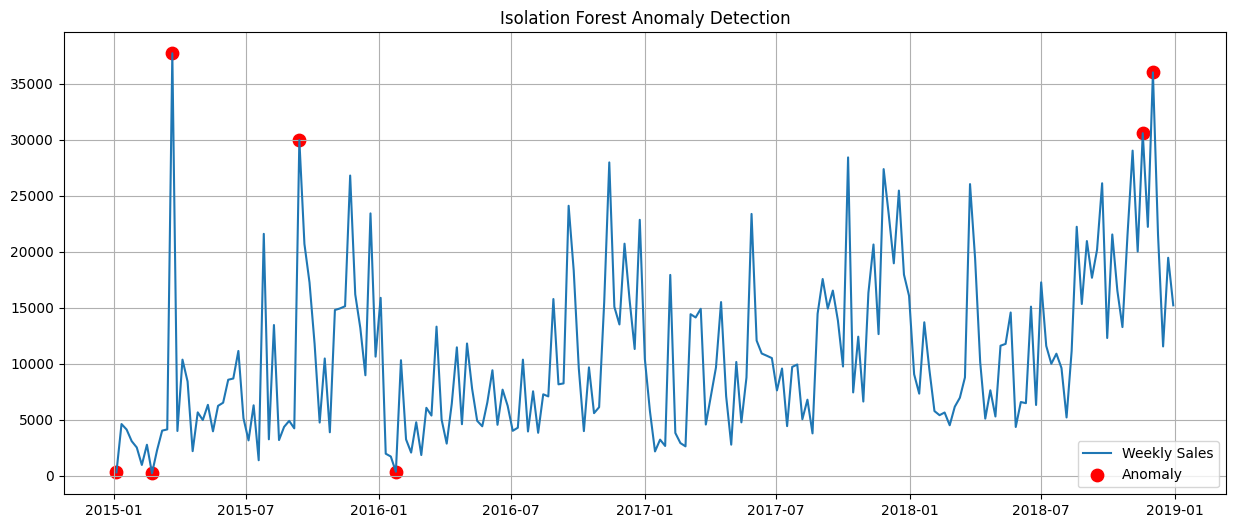

In [80]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

anomalies = weekly_sales[
    weekly_sales["Anomaly"] == -1
]

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.legend()

plt.grid(True)

plt.show()

In [81]:
anomalies

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
202,2018-11-18,30572.447,-1
204,2018-12-02,35998.900,-1


In [82]:
weekly_sales["RollingMean"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .mean()
)

weekly_sales["RollingStd"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .std()
)

In [83]:
weekly_sales["ZScore"] = (
    (
        weekly_sales["Sales"]
        - weekly_sales["RollingMean"]
    )
    /
    weekly_sales["RollingStd"]
)

In [84]:
weekly_sales["Z_Anomaly"] = (
    weekly_sales["ZScore"].abs() > 2
)

weekly_sales.head()

,Order Date,Sales,Anomaly,RollingMean,RollingStd,ZScore,Z_Anomaly
0,2015-01-04,304.508,-1,NaN,NaN,NaN,False
1,2015-01-11,4619.108,1,NaN,NaN,NaN,False
2,2015-01-18,4130.533,1,NaN,NaN,NaN,False
3,2015-01-25,3092.544,1,3036.67325,1929.462566,0.028957,False
4,2015-02-01,2527.914,1,3592.52475,953.362968,-1.116690,False


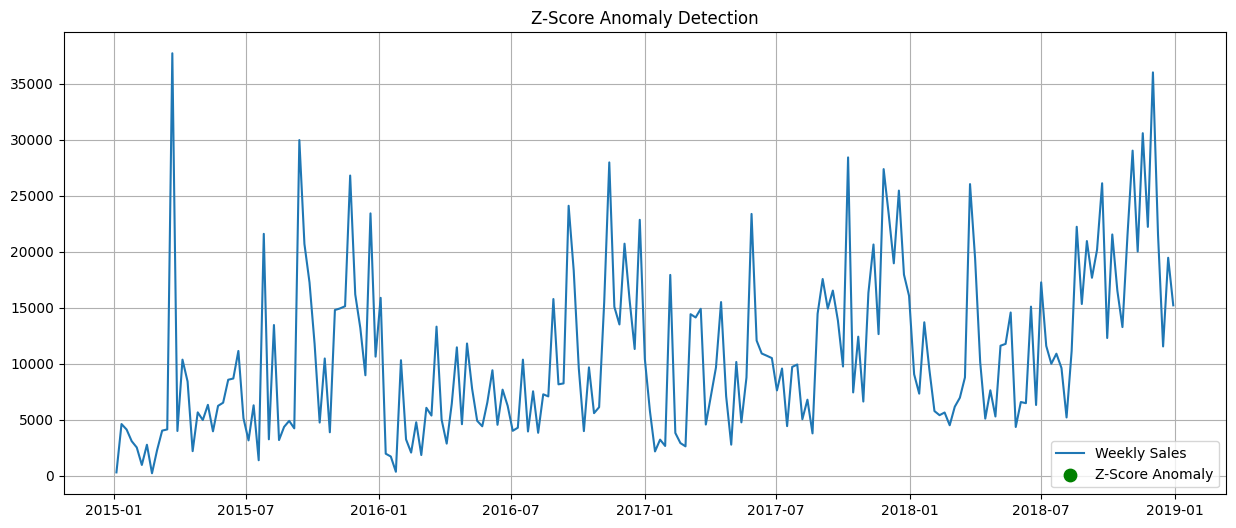

In [85]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

z = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

plt.scatter(
    z["Order Date"],
    z["Sales"],
    color="green",
    s=80,
    label="Z-Score Anomaly"
)

plt.legend()

plt.title("Z-Score Anomaly Detection")

plt.grid(True)

plt.show()

In [86]:
print("Isolation Forest Anomalies")

print(
    weekly_sales[
        weekly_sales["Anomaly"] == -1
    ][["Order Date", "Sales"]]
)

print()

print("Z-Score Anomalies")

print(
    weekly_sales[
        weekly_sales["Z_Anomaly"]
    ][["Order Date", "Sales"]]
)

Isolation Forest Anomalies
    Order Date      Sales
0   2015-01-04    304.508
7   2015-02-22    224.912
11  2015-03-22  37703.665
36  2015-09-13  29959.137
55  2016-01-24    358.522
202 2018-11-18  30572.447
204 2018-12-02  35998.900

Z-Score Anomalies
Empty DataFrame
Columns: [Order Date, Sales]
Index: []


In [87]:
weekly_sales.to_csv(
    "anomaly_report.csv",
    index=False
)

print("Report Saved")

Report Saved


### Anomaly Detection Observations

1. Isolation Forest detected unusually high and low sales weeks.
2. Z-Score identified weeks where sales deviated by more than two standard deviations from the rolling average.
3. Some anomalies were detected by both methods, while others appeared in only one method.
4. Large sales spikes may correspond to festive seasons, promotional events, or major discount campaigns.
5. Sharp declines may indicate holidays, supply shortages, or operational disruptions.

In [91]:
product_data = (
    df.groupby("Sub-Category")
      .agg(
          Total_Sales=("Sales","sum"),
          Average_Sales=("Sales","mean"),
          Sales_Volatility=("Sales","std")
      )
      .reset_index()
)

product_data["Sales_Volatility"] = product_data["Sales_Volatility"].fillna(0)

product_data.head()

,Sub-Category,Total_Sales,Average_Sales,Sales_Volatility
0,Accessories,164186.7000,217.178175,337.723800
1,Appliances,104618.4030,227.926804,378.006735
2,Art,26705.4100,34.019631,60.301752
3,Binders,200028.7850,134.067550,568.099970
4,Bookcases,113813.1987,503.598224,641.419280


In [92]:
from sklearn.preprocessing import StandardScaler

features = [
    "Total_Sales",
    "Average_Sales",
    "Sales_Volatility"
]

scaler = StandardScaler()

scaled_data = scaler.fit_transform(product_data[features])

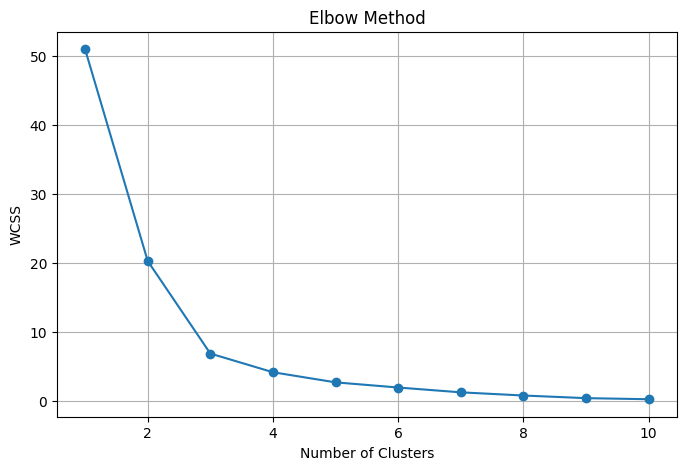

In [93]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    model.fit(scaled_data)
    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [94]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_data["Cluster"] = kmeans.fit_predict(scaled_data)

product_data.head()

,Sub-Category,Total_Sales,Average_Sales,Sales_Volatility,Cluster
0,Accessories,164186.7000,217.178175,337.723800,2
1,Appliances,104618.4030,227.926804,378.006735,1
2,Art,26705.4100,34.019631,60.301752,1
3,Binders,200028.7850,134.067550,568.099970,2
4,Bookcases,113813.1987,503.598224,641.419280,2


In [95]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

points = pca.fit_transform(scaled_data)

product_data["PC1"] = points[:,0]
product_data["PC2"] = points[:,1]

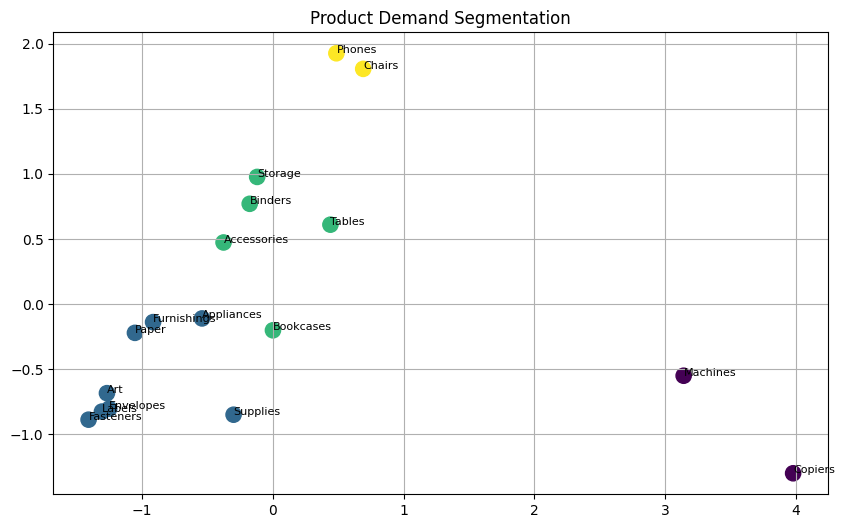

In [96]:
plt.figure(figsize=(10,6))

plt.scatter(
    product_data["PC1"],
    product_data["PC2"],
    c=product_data["Cluster"],
    s=120
)

for i in range(len(product_data)):
    plt.text(
        product_data.loc[i,"PC1"],
        product_data.loc[i,"PC2"],
        product_data.loc[i,"Sub-Category"],
        fontsize=8
    )

plt.title("Product Demand Segmentation")
plt.grid(True)
plt.show()

In [97]:
labels = {
    0:"High Volume Stable",
    1:"Growing Demand",
    2:"Low Volume",
    3:"Declining"
}

product_data["Cluster Name"] = product_data["Cluster"].map(labels)

product_data

,Sub-Category,Total_Sales,Average_Sales,Sales_Volatility,Cluster,PC1,PC2,Cluster Name
0,Accessories,164186.7000,217.178175,337.723800,2,-0.378093,0.473542,Low Volume
1,Appliances,104618.4030,227.926804,378.006735,1,-0.542587,-0.109670,Growing Demand
2,Art,26705.4100,34.019631,60.301752,1,-1.270204,-0.683449,Growing Demand
3,Binders,200028.7850,134.067550,568.099970,2,-0.177997,0.770494,Low Volume
4,Bookcases,113813.1987,503.598224,641.419280,2,-0.000108,-0.200835,Low Volume
5,Chairs,322822.7310,531.833165,551.180296,3,0.690373,1.806529,Declining
6,Copiers,146248.0940,2215.880212,3216.185499,0,3.979711,-1.298575,High Volume Stable
7,Envelopes,16128.0460,65.032444,85.170691,1,-1.252992,-0.802678,Growing Demand
8,Fasteners,3001.9600,14.027850,12.466864,1,-1.410766,-0.886936,Growing Demand
9,Furnishings,89212.0180,95.823865,148.421490,1,-0.917338,-0.137973,Growing Demand
